# **<span style="color: #000000;background-color: #fff5b1">회귀 심화 사전과제</span>**

#### **필수내용**
- 다중선형회귀의 기본 가정 여섯가지
- 회귀 분석의 평가 방법
    - 시각화
    - 통계지표 : 유의성 검정, 성능평가
- 비선형 회귀 모델
    - 다항, 지수, 로그, 스플라인

---

### <span style="color: #000000;background-color: #ffdba4">**1. 선형회귀**</span>

##### <span style="color: #000000;background-color: #ffc2e5">   **1-(1) 다중선형회귀의 수식적 이해**</span> 
$$y_i = \beta_0+\beta_1X_{1i}+\beta_2X_{2i}+...+\beta_kX_{ki}+\varepsilon_i
$$  
- $y_i$ : i번째 **종속 변수**(우리가 관심 있는 값)
- $X_{1i}, X_{2i}, ... , X_{ki}$ : i번째 y에 대한 여러 개의 **설명변수**(독립 변수)
- $\beta_0$ : **절편**, 설명변수(X)가 모두 0일 때 y의 값
- $\beta_k$ : 설명변수에 의한 **회귀 계수** (각 변수 X의 영향력)
- $\epsilon_i$  : **오차항**
> -> y에 대해 영향을 줄 것 같은 여러 독립변수를 채택하여 선형적으로 식을 작성한 것!

$$y=w_0x_0+w_1x_1+\cdot\cdot\cdot+w_mx_m=\sum_{i=0}^mw_ix_i=w^Tx
$$
> -> 위 식에서 상수항과 오차항을 제외한 식
- 선형회귀식 = 종속변수 y에 대한 독립변수들의 가중평균
    - x에 w를 곱해 더함으로써 <U>**y를 얼마나 잘 설명하는지**</U>를 설명한다!

<BR>

<span style="color: #ff0000"> **그러나 모든 상황에서 선형회귀를 쓸 수 있는 것은 아님!!**</span>

##### <span style="color: #000000;background-color: #ffc2e5">   **1-(2) 다중선형회귀의 기본 가정 6가지**</span> 
<U>**다음 가정을 만족하지 않으면 분석 결과의 신뢰성이 떨어지고, 심각하면 분석 자체가 불가능해진다.**</U>


##### <span style="color: #27baff">   **i. 선형성(Linearity)**</span>
- 종속변수와 설명변수 간의 관계가 **선형적**이어야 한다는 가정  
<BR>
$E(y|X) = \beta_1+\beta_2X_2+...+\beta_nX_n$

##### <span style="color: #27baff"> **ii. 독립성(Independence)**</span>
- 각각의 설명변수가 서로 **선형독립적**이어야 한다는 가정
- $X_i, X_j \ is \ linearly\ independent \ for\ all \ i,j$  
 <BR>
- 선형독립적이지 않으면 <U>다중공선성이 있다</U> 

##### <span style="color: #27baff"> **iii. 오차항의 평균은 0이다(0에 가까워야 한다)**</span>
- 오차항의 평균은 0이거나 0에 가까워야 한다는 가정
- $E(\varepsilon_i|X_i) = 0$ 
    - 오차항(백색 잡음) : 실제 값과 예측 값의 차이  


##### <span style="color: #27baff"> **iv. 등분산성(Homoscedasticity)**</span>
- **오차항의 분산이 일정**해야 한다는 가정
- $Var(\varepsilon_i|X_i) = \sigma^2$  
<BR>
- 일정하지 않으면 <U>이분산성이 있다</U> -> 특히, 횡단면 자료에서 많이 나타남
    - 회귀 분석의 결과가 정확하지 않을 수 있음  

##### <span style="color: #27baff"> **v. 오차항은 자기상관되어 있지 않다. (Non-autocorrelation)**</span>
- **오차항의 공분산은 항상 0**이어야 된다는 가정
- $Cov(\varepsilon_i, \varepsilon_j|X_i) =0$  
    - 공분산 : 두 변수 간의 상관된 정보를 나타내는 지표
        - 양의 상관관계 - x가 증가하면 y도 증가  
        - 음의 상관관계 - x가 증가하면 y는 감소
        - 공분산 = 0 - x와 y가 독립적인 관계

- 공분산이 0이 아니면 <U>자기상관이 있다</U>
    - 자기 상관 : 한 변수의 현재 값이 과거 값과 상관관계를 가지는 현상 -> 특히 시계열 자료에서 많이 나타남
    - 모델이 이전 데이터의 패턴을 학습해서 반복적인 오류를 만들어 낼 수 있음


##### <span style="color: #27baff"> **vi. 정규성(Normality) - 선택**</span>
- **오차항이 정규분포를 따른다**는 가정
- $\varepsilon_i \sim N(0, \sigma^2)$  
<BR>
- 위배되어도 다중선형회귀 분석의 결과에 큰 영향을 주지 않음
- 회귀계수들의 신뢰구간과 p-value는 정규성을 따라 만들어진 것 -> 정규성을 만족한다는 가정을 따르지 않으면, p-value가 잘못 계산될 수 있음

##### <span style="color : #000000;background: #27baff"> **회귀 분석 전 vs 후 검증해야할 가정 정리**</span>

|기본 가정|분석 전 검증 가능?|분석 후 검증 가능?|검증 방법|
|---|---|---|---|
|선형성|O|O|scattor plot|
|독립성|O|O|VIF 지수, 상관계수|
|오차항 평균=0|X|O|np.mean(residuals)|
|등분산성|X|O|잔차의 도표화|
|오차항은 자기상관 없다|간접적으로 가능|O|Durbin-Watson 검정|
|정규성|X|O|Shapiro=Wilk 검증, Q-Q plot|

- 위 표의 기준 : *'오차항에 대한 가정인가?'*
- 회귀식 :  $y = \beta_0 + \beta_1X + \epsilon$
    - 오차항 $\epsilon$은 모델 학습 후에 정해짐
    - 즉, 모델 학습 전에는 **오차항을 계산할 수 있는 근거가 없다**

##### <span style="color: #000000;background-color: #ffc2e5">   **1-(3) 회귀분석 평가 방법**</span> 
##### <span style="color: #27baff">   **i. 시각화**</span>
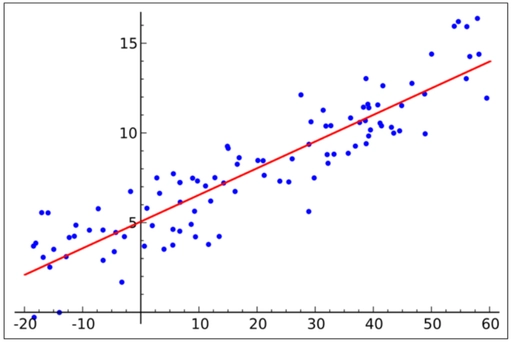<BR>
<그래프 1><BR>
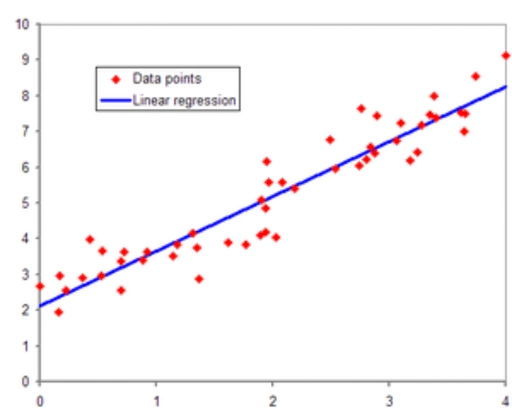<BR>
<그래프 2><BR>
- 회귀선이 데이터 전반을 잘 요약하긴 하지만 둘 중 어느 회귀선이 해당 데이터를 더 잘 요약하는지 객관적으로 비교 어려움. -> **통계지표**를 활용하자!


##### <span style="color: #27baff">   **ii. 통계지표**</span>
<span style="color: #27ff35">   **(1) 모델 유의성 검정**</span><BR>
- **F-statistic, Prob(F_statistic)**
    - <U>회귀 모델이 유의미한지(종속변수와 전체 독립 변수 간의 관계가 통계적으로 유의미한지) 검정하는 지표</U> 
    - <span style = "color: #ff0000"> **모델 전체에 대한 평가** </span>
        - 귀무가설 : 모든 회귀계수가 0이다.
        - 대립가설 : 적어도 하나의 회귀 계수는 0이 아니다.
    - F-statistic의 값이 클수록 통계적으로 유의미하다
    - Prob(F-statistic) : F-statistic의 p-value
        - Prob < 0.05 => 귀무가설 기각 = 회귀 모델이 유의미  
<BR>
- **T-statistic, Prob(T_statistic)**
    - <U>각 독립변수가 종속변수 y에 유의미한 영향을 미치는지 판단하는 지표</U>  
    - <span style = "color: #ff0000"> **개별 변수의 유의성에 대한 평가** </span>
        - 귀무가설 : 해당 변수의 회귀 계수가 0이다.
        - 대립가설 : 해당 변수의 회귀 계수는 0이 아니다.
    - P>|T-statistic|을 0.05 기준으로 가설 검정
        - 0.05보다 작다 => 귀무가설 기각 = 해당 변수가 종속 변수에 유의미한 영향을 미친다  
<BR>

<span style="color: #27ff35">   **(2) 모델 성능 평가**</span><BR>
- **결정 계수 (R-squared, $R^2$)**
    - 회귀 모델이 <U>**종속 변수의 전체 변동성을 얼마나 잘 설명하는지**</U> 나타내는 지표  
    - 단순히 평균값으로 데이터를 예측했을 때보다, 모델을 활용했을 때 오차가 얼마나 줄어드는지를 수치화한 것
    + $R^2 = SSR/SST = 1-SSE/SST$  
        - SST : 평균으로 예측했을 때의 총 오차  
        - SSE : 모델이 예측하고도 여전히 남은 오차 (모델의 한계)  
        - SSR : 평균에 비해 회귀 모델이 얼마나 더 잘 맞혔는지 (모델의 성과)  
    - 0 $\leq R^2 \leq 1$
    - R^2가 1에 가깝다 = 데이터를 잘 설명한다
    - R^2가 0이다 = 모델이 데이터를 전혀 설명하지 못한다.<BR>
<BR>
- **조정된 결정 계수 (Adjusted R-squared, Adjusted $R^2$)**
    - *R-squared 값이 높기만 하면 무조건 좋을까?*
    - ### **NO!!**
    - R^2는 독립 변수의 개수가 증가하면 자연스레 증가 => 데이터와 큰 관련성이 없는 변수를 추가해도 R-squared 값이 높아지는 현상이 생긴다.
    - <U>변수의 개수 증가에 덜 민감하도록 조정한 지표</U>가 **Adjusted $R^2$**


    - 식 : $\overline{R}^2 = \frac{SSR}{SST}\frac{n-1}{n-k}=1-(\frac{SSE/(n-k)}{SST/(n-1)})$
        - n:샘플 수, k : 독립변수의 개수
    - 변수의 개수가 증가하면 전체 값 감소 -> 변수 개수에 따른 설명력 추가 부분을 상쇄!
        - 변수를 추가했을 때, SSE가 감소하면 (SSE/(n-k))가 작아짐 -> R-squared 값 증가
        - 변수를 추가했을 때, SSE가 거의 그대로라면 (SSE/(n-k))가 커짐 (SSE는 동일하고 n-k가 작아지니까)-> R-squared 값 감소<BR>
<BR>
- **AIC, BIC(SC)**
    - 두 지표의 값이 낮을수록 좋다고 평가
    - AIC (Akaike information criterion)
        - BIC에 비해 복잡성에 대한 패널티가 비교적 작다.
    - BIC(SC) : BIC(Bayesian information criterion), SC(Schwarz Criterion)
        - AIC보다 더 엄격한 기준, 데이터의 양에 따라 더 강한 패널티 부과


### <span style="color: #000000;background-color: #ffdba4">**2. 비선형회귀**</span>

##### <span style="color: #000000;background-color: #ffc2e5">   **2-(1) 다항식 회귀 모델 (Polynomial Regression Model)**</span> 
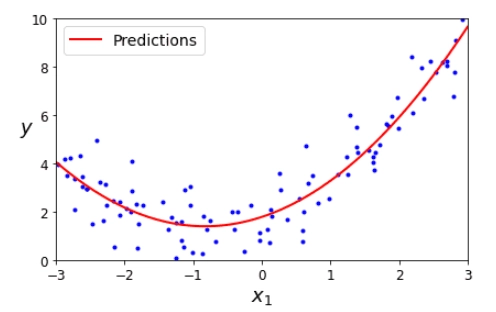  
- $Y = a+bX+cX^2+dX^3+ ...$
- 독립변수에 거듭제곱 항을 추가하여 데이터의 **곡선적 특성**을 모델링
- 사용 방법
    1. $Y=a+bX$에 대해 $cX^2, dX^3$ 등을 포함하여 모델 확장
    2. 확장한 상태에 선형 회귀 적용
- 장점 : 선형 모델에 비해 회귀선을 데이터에 fit하게 그릴 수 있다.
- 단점 : 너무 많은 feature를 이용하면 결과가 overfitting 될 수 있다.
- 적합한 상황
    - 곡선을 그리는 데이턴 패턴에 유용
    - 성장률, 감소율 등

##### <span style="color: #000000;background-color: #ffc2e5">   **2-(2) 지수 회귀 모델 (Exponential Model)**</span> 
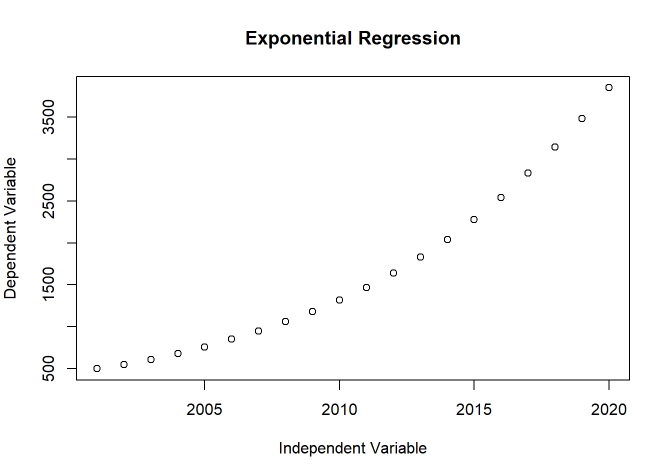  
- 종속 변수가 지수적으로 변화하는 관계를 모델링할 때 사용
- 사용 방법
    - 수식 : $Y=ae^{bX}$
        - 위 식의 양변에 로그를 취하면 $\ln Y=\ln a+bX$ -> $\ln Y$와 $\ln a$를 각각 새로운 변수로 보면 선형회귀 식과 비슷하다!
    1. 종속 변수 Y에 로그를 취한 후, 선형회귀를 적용
    2. Y 값 예측 시, 원래의 데이터 형태로 복구하기 위해 예측 값($\ln Y$)에 지수함수를 적용
- 적합한 상황
    - 값이 시간에 따라 지수적으로 증가하거나 감소하는 경우
    - 기술 발전, 투자 수익률 증가 등

##### <span style="color: #000000;background-color: #ffc2e5">   **2-(3) 로그 회귀 모델 (Log Regression Model)**</span> 
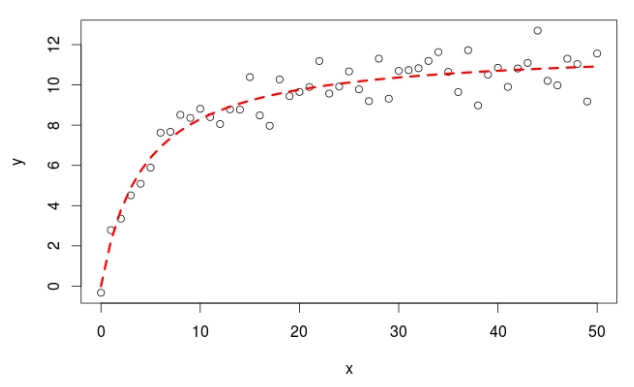  
- 종속 변수와 독립 변수 간의 관계가 로그함수를 통해 더 잘 표현될 때 사용
- 사용 방법
    - 수식 :  $Y=a+b\log(X)$
        - 선형회귀식에서 X 자리에 $\log(X)$가 들어간 것
    1. 독립 변수 X에 로그함수 적용
    2. 선형 회귀 적용
    3. 예측된 값은 별도의 처리를 하지 않고 그대로 사용
- 적합한 상황
    - 데이터가 초기에 빠르게 증가하고 점차 증가율이 줄어드는 패턴을 보일 때
    - 인구 성장, 감염병의 확산 등

##### <span style="color: #000000;background-color: #ffc2e5">   **2-(4) 스플라인 회귀 (Spline Regression)**</span> 
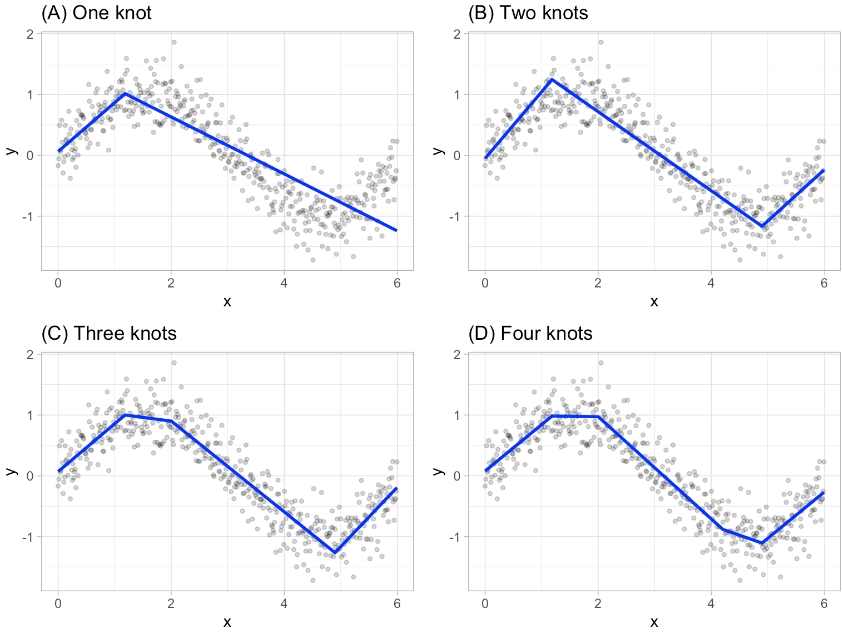  
- 데이터를 구간별로 나누고 각 구간에서 다른 선형 또는 비선형 함수를 적용하여 예측하는 방식
- 사용 방법
    - 전체 데이터 범위를 여러 구간으로 나누고, 각 구간에 대해 별도의 회귀모델 적용
    - 구간 경계에서의 **연속성을 유지** 하는 것이 중요!
    - $Y = \begin{cases} a_1 + b_1X & \text{if } X < c_1 \\a_2 + b_2X & \text{if } c_1 \leq X < c_2 \\\cdots \\a_n + b_nX & \text{if } X \geq c_{n-1}\end{cases}$
- 적합한 상황
    - 데이터 패턴이 여러 구간에서 서로 다르게 나타날 때
    - 계절에 따라 판매량이 변화하는 소매 데이터 분석 등
